**1. Imports**

In [1]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

2026-05-16 02:21:16.481812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778898076.672604      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778898076.741840      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778898077.231332      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778898077.231370      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778898077.231373      57 computation_placer.cc:177] computation placer alr

**2. Prepare Dataset (Fashion MNIST)**

In [2]:
(x_train, _), _ = keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)  # (28, 28, 1)

batch_size = 128
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(buffer_size=1024).batch(batch_size)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


I0000 00:00:1778898105.447456      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


**3. Build the Generator**

In [3]:
latent_dim = 10

def build_generator():
    model = keras.Sequential([
        layers.Dense(7 * 7 * 128, activation="relu", input_shape=(latent_dim,)),
        layers.Reshape((7, 7, 128)),
        layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu"),
        layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu"),
        layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid"),
    ])
    return model

generator = build_generator()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │        68,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           577 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,945 (1.11 MB)

 Trainable params: 290,945 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

**4. Build the Discriminator**

In [4]:
def build_discriminator():
    model = keras.Sequential([
        layers.Conv2D(64, 3, strides=2, padding="same", activation="relu",
                      input_shape=(28, 28, 1)),
        layers.Conv2D(128, 3, strides=2, padding="same", activation="relu"),
        layers.Flatten(),
        layers.Dense(1, activation="sigmoid"),
    ])
    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,769 (315.50 KB)

 Trainable params: 80,769 (315.50 KB)

 Non-trainable params: 0 (0.00 B)

**5. Define GAN Model (Custom Training Loop)**

In [5]:
class GAN(keras.Model):
    def __init__(self, generator, discriminator):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.loss_fn = keras.losses.BinaryCrossentropy()
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]

        # ---------------------
        # Train Discriminator
        # ---------------------
        random_latent = tf.random.normal(shape=(batch_size, latent_dim))
        fake_images = self.generator(random_latent)

        combined_images = tf.concat([real_images, fake_images], axis=0)
        labels = tf.concat(
            [tf.ones((batch_size, 1)) * 0.9, tf.zeros((batch_size, 1))], axis=0
        )

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)

        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        # ---------------------
        # Train Generator
        # ---------------------
        random_latent = tf.random.normal(shape=(batch_size, latent_dim))
        misleading_labels = tf.ones((batch_size, 1))  # want fake to look real

        with tf.GradientTape() as tape:
            fake_images = self.generator(random_latent)
            predictions = self.discriminator(fake_images)
            g_loss = self.loss_fn(misleading_labels, predictions)

        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)

        return {"d_loss": self.d_loss_tracker.result(),
                "g_loss": self.g_loss_tracker.result()}

**6. Train the GAN**

In [6]:
gan = GAN(generator, discriminator)

gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
)

gan.fit(dataset, epochs=50)

Epoch 1/50


I0000 00:00:1778898109.322890     128 service.cc:152] XLA service 0x7aab0400eb70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778898109.322940     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778898109.923892     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


 16/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - d_loss: 0.6479 - g_loss: 0.8948

I0000 00:00:1778898113.593341     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - d_loss: 0.4194 - g_loss: 1.9307
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - d_loss: 0.3347 - g_loss: 3.0102
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - d_loss: 0.2763 - g_loss: 3.3443
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - d_loss: 0.2528 - g_loss: 3.2914
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - d_loss: 0.3808 - g_loss: 2.4201
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - d_loss: 0.5096 - g_loss: 1.6194
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - d_loss: 0.5172 - g_loss: 1.4976
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - d_loss: 0.5657 - g_loss: 1.4107
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - d_loss: 0.5601 - g_loss: 1.3710
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - d_loss: 0.5395 - g_loss: 1.5030
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - d_loss: 0.5264 - g_loss: 1.5313
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/st

**7. Generate and Visualize Samples**

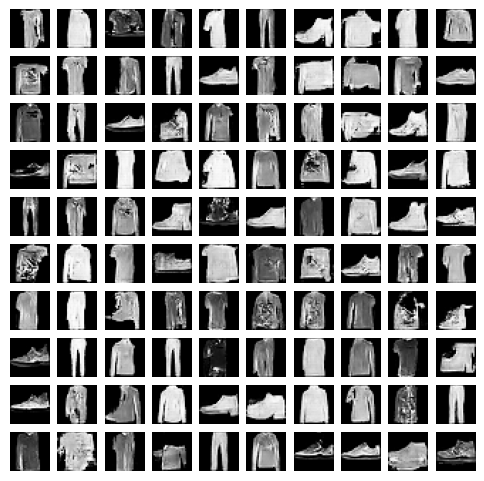

In [7]:
def plot_generated_images(generator, n=10):
    noise = tf.random.normal(shape=(n * n, latent_dim))
    generated_images = generator.predict(noise, verbose=0)

    plt.figure(figsize=(6, 6))
    for i in range(n * n):
        plt.subplot(n, n, i + 1)
        plt.imshow(generated_images[i].squeeze(), cmap="gray")
        plt.axis("off")
    plt.show()

plot_generated_images(generator)